In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [18]:
df = pd.read_csv('/content/data/citrus.csv')

print("Jumlah data:", df.shape)
df.head()

Jumlah data: (10000, 6)


,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [20]:
df.describe()

,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


In [21]:
df['name'].value_counts()

,count
name,
orange,5000
grapefruit,5000


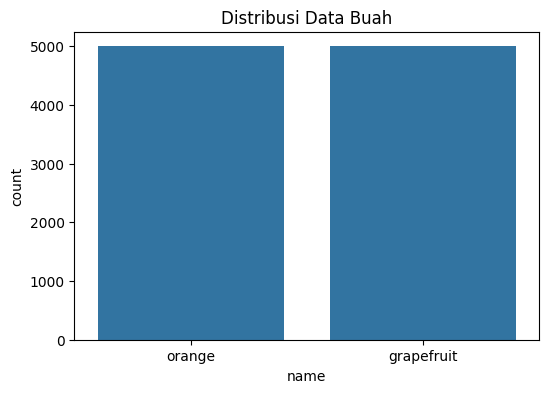

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='name', data=df)
plt.title("Distribusi Data Buah")
plt.show()

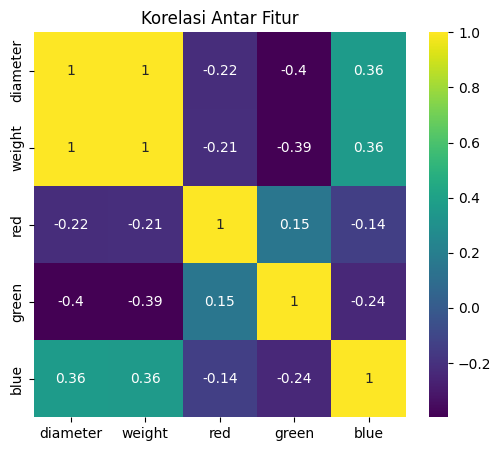

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='viridis')
plt.title("Korelasi Antar Fitur")
plt.show()

In [25]:
encoder = LabelEncoder()
df['name'] = encoder.fit_transform(df['name'])

In [26]:
X = df.drop('name', axis=1)
y = df['name']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

results = {}

print("=== HASIL EVALUASI MODEL ===\n")

for nama, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    results[nama] = acc

    print(f"{nama}: {acc:.4f}")

=== HASIL EVALUASI MODEL ===

Decision Tree: 0.9435
Naive Bayes: 0.9200
SVM: 0.9370


In [30]:
results

{'Decision Tree': 0.9435, 'Naive Bayes': 0.92, 'SVM': 0.937}

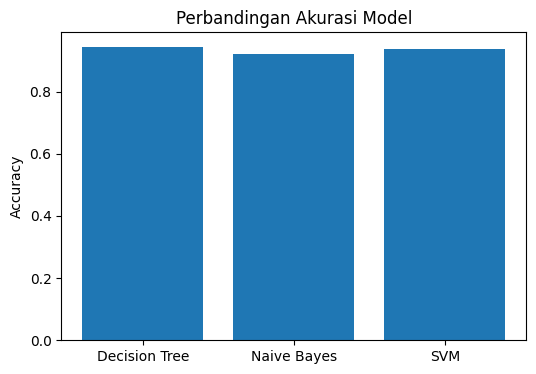

In [31]:
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.show()

In [32]:
best_model = max(results, key=results.get)
print("Model terbaik:", best_model)

Model terbaik: Decision Tree


In [33]:
print("""
Kesimpulan:

1. Semua model mampu melakukan klasifikasi dengan baik.
2. Decision Tree memberikan performa terbaik pada dataset ini.
3. SVM juga menunjukkan hasil yang kompetitif.
4. Naive Bayes memiliki performa paling rendah karena asumsi independensi fitur.

Dataset yang seimbang membantu model belajar dengan lebih optimal.
""")


Kesimpulan:

1. Semua model mampu melakukan klasifikasi dengan baik.
2. Decision Tree memberikan performa terbaik pada dataset ini.
3. SVM juga menunjukkan hasil yang kompetitif.
4. Naive Bayes memiliki performa paling rendah karena asumsi independensi fitur.

Dataset yang seimbang membantu model belajar dengan lebih optimal.



In [34]:
print("Notebook berhasil dijalankan tanpa error ✅")

Notebook berhasil dijalankan tanpa error ✅
